# 02 — Bias Analysis: CREMA-D + CMU-MOSI

This notebook performs **representation-level modality ablation** and **layer-wise representation bias analysis** for both datasets using the exact baseline architectures/checkpoints already used in the project.

**CREMA-D:** Audio + Visual, 6 emotion classes, exact repository speaker-independent test split.

**CMU-MOSI:** Text + Audio + Vision, 3 sentiment classes, exact repository `aligned_50.pkl` preprocessing and baseline checkpoint.

Important: MBS and XAI remain independent. This notebook does not redefine MBS from attribution scores.

### Outputs
- Per-sample modality ablation CSVs for both datasets
- Ablation summary CSVs and plots
- Layer-wise representation energy/share and bias CSVs and plots
- Optional merge with Notebook 3 XAI/MBS results
- One final cross-dataset comparison table

In [ ]:
# ============================================================
# CELL 1 — SETUP, REPOSITORY, PATHS, AND RAW CREMA-D DATA
# ============================================================

!pip -q install gdown huggingface_hub librosa soundfile opencv-python-headless scipy scikit-learn pandas matplotlib

import os
import json
import random
import shutil
import subprocess
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from huggingface_hub import hf_hub_download

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ------------------------------------------------------------
# Repository
# ------------------------------------------------------------
REPO_URL = "https://github.com/Vaishnavi23457/DL_project.git"
REPO_DIR = Path("/content/DL_project")

if not REPO_DIR.exists():
    !git clone -q {REPO_URL} {REPO_DIR}

PROJECT_DIR = REPO_DIR / "modality_bias"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CREMA_CKPT = CHECKPOINT_DIR / "crema_d_baseline_best.pth"
METADATA_PATH = RESULTS_DIR / "crema_d_metadata.csv"
MBS_PATH = RESULTS_DIR / "mbs_per_sample.csv"

assert CREMA_CKPT.exists(), f"Missing checkpoint: {CREMA_CKPT}"
assert METADATA_PATH.exists(), f"Missing metadata: {METADATA_PATH}"

print("Checkpoint:", CREMA_CKPT)
print("Metadata:", METADATA_PATH)
print("MBS:", MBS_PATH, "exists=" + str(MBS_PATH.exists()))

# ------------------------------------------------------------
# Download the same public CREMA-D mirror used by the XAI notebook
# ------------------------------------------------------------
CREMA_GDRIVE_ID = "1MPiFfSiEanCNu5HSon5Y2dGHsnpsUtRm"
CREMA_WORK = Path("/content/crema_d_bias_data")
CREMA_ARCHIVE = CREMA_WORK / "crema-d.zip"
CREMA_WORK.mkdir(parents=True, exist_ok=True)

audio_dirs = list(CREMA_WORK.rglob("AudioWAV"))
video_dirs = list(CREMA_WORK.rglob("VideoFlash"))

if not audio_dirs or not video_dirs:
    print("CREMA-D raw media not found. Downloading...")
    if not CREMA_ARCHIVE.exists():
        subprocess.run(
            ["gdown", "--id", CREMA_GDRIVE_ID, "-O", str(CREMA_ARCHIVE)],
            check=True
        )
    subprocess.run(
        ["unzip", "-q", "-o", str(CREMA_ARCHIVE), "-d", str(CREMA_WORK)],
        check=True
    )

audio_dirs = list(CREMA_WORK.rglob("AudioWAV"))
video_dirs = list(CREMA_WORK.rglob("VideoFlash"))

if not audio_dirs or not video_dirs:
    raise RuntimeError(
        "CREMA-D download/extraction completed, but AudioWAV/VideoFlash "
        "directories were not found."
    )

AUDIO_DIR = audio_dirs[0]
VIDEO_DIR = video_dirs[0]

print("Audio directory:", AUDIO_DIR)
print("Video directory:", VIDEO_DIR)


# ------------------------------------------------------------
# CMU-MOSI source used by the repository baseline notebook
# ------------------------------------------------------------
CMU_CKPT = CHECKPOINT_DIR / "cmu_mosi_baseline_best.pth"
CMU_MBS = RESULTS_DIR / "cmu_mosi" / "cmu_mosi_test_mbs.csv"
CMU_REPO_ID = "tamb2203579/CMU-MOSI"
CMU_REMOTE_FILE = "Processed/aligned_50.pkl"
CMU_WORK = Path("/content/cmu_mosi_bias_data")
CMU_PKL = CMU_WORK / "Processed" / "aligned_50.pkl"
CMU_WORK.mkdir(parents=True, exist_ok=True)

print("CMU checkpoint:", CMU_CKPT, "exists=" + str(CMU_CKPT.exists()))
print("CMU MBS:", CMU_MBS, "exists=" + str(CMU_MBS.exists()))


Device: cpu
Checkpoint: /content/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth
Metadata: /content/DL_project/modality_bias/results/crema_d_metadata.csv
MBS: /content/DL_project/modality_bias/results/mbs_per_sample.csv exists=True
CREMA-D raw media not found. Downloading...
Audio directory: /content/crema_d_bias_data/datasets/CREMA-D/AudioWAV
Video directory: /content/crema_d_bias_data/datasets/CREMA-D/VideoFlash
CMU checkpoint: /content/DL_project/modality_bias/checkpoints/cmu_mosi_baseline_best.pth exists=True
CMU MBS: /content/DL_project/modality_bias/results/cmu_mosi/cmu_mosi_test_mbs.csv exists=True


In [ ]:
# ============================================================
# CELL 2 — EXACT CREMA-D TEST SPLIT + PREPROCESSING + DATASET
# ============================================================

# ------------------------------------------------------------
# Authoritative split from the repository
# ------------------------------------------------------------
metadata = pd.read_csv(METADATA_PATH)

required_cols = {
    "id", "video", "audio", "speaker", "label", "emotion", "split"
}

missing = required_cols - set(metadata.columns)
if missing:
    raise ValueError(f"CREMA-D metadata missing columns: {missing}")

crema_test_meta = metadata[
    metadata["split"].astype(str).str.lower().eq("test")
].copy()

crema_test_meta["id"] = crema_test_meta["id"].astype(str)
crema_test_meta["label"] = crema_test_meta["label"].astype(int)

# Build raw-media paths from authoritative sample IDs.
crema_test_meta["audio_path"] = crema_test_meta["id"].map(
    lambda stem: str(AUDIO_DIR / f"{stem}.wav")
)
crema_test_meta["video_path"] = crema_test_meta["id"].map(
    lambda stem: str(VIDEO_DIR / f"{stem}.flv")
)

assert len(crema_test_meta) == 1065, (
    f"Expected 1065 test samples, got {len(crema_test_meta)}"
)
assert crema_test_meta["id"].is_unique

missing_audio = crema_test_meta.loc[
    ~crema_test_meta["audio_path"].map(os.path.exists), "id"
].tolist()

missing_video = crema_test_meta.loc[
    ~crema_test_meta["video_path"].map(os.path.exists), "id"
].tolist()

if missing_audio or missing_video:
    raise FileNotFoundError(
        f"Missing CREMA-D media: "
        f"audio={missing_audio[:5]}, video={missing_video[:5]}"
    )

print("✓ Exact repository test split")
print("Test samples:", len(crema_test_meta))
print("Test speakers:", crema_test_meta["speaker"].nunique())
print(
    "Speakers:",
    sorted(crema_test_meta["speaker"].astype(int).unique().tolist())
)

# ------------------------------------------------------------
# Exact preprocessing used by the XAI notebook
# ------------------------------------------------------------
AUDIO_SR = 16000
AUDIO_SECONDS = 4
N_MELS = 64
NUM_FRAMES = 8
IMAGE_SIZE = 224

imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

def load_audio_exact(path):
    y, sr = librosa.load(
        path,
        sr=AUDIO_SR,
        mono=True
    )

    target_len = AUDIO_SR * AUDIO_SECONDS

    if len(y) < target_len:
        y = np.pad(
            y,
            (0, target_len - len(y))
        )
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=AUDIO_SR,
        n_mels=N_MELS,
        n_fft=1024,
        hop_length=256
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    ).astype(np.float32)

    mel = (
        mel - mel.mean()
    ) / (
        mel.std() + 1e-6
    )

    return torch.from_numpy(mel).unsqueeze(0).float()


def load_video_exact(path):
    cap = cv2.VideoCapture(path)
    total = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total <= 0:
        cap.release()
        raise RuntimeError(
            f"Could not read video: {path}"
        )

    indices = np.linspace(
        0,
        max(total - 1, 0),
        NUM_FRAMES
    ).astype(int)

    frames = []

    for idx in indices:
        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(idx)
        )

        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frame = cv2.resize(
            frame,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        frames.append(frame)

    cap.release()

    if not frames:
        raise RuntimeError(
            f"No frames decoded: {path}"
        )

    while len(frames) < NUM_FRAMES:
        frames.append(
            frames[-1].copy()
        )

    arr = (
        np.stack(
            frames[:NUM_FRAMES]
        ).astype(np.float32)
        / 255.0
    )

    x = torch.from_numpy(arr).permute(
        0, 3, 1, 2
    )

    x = torch.stack([
        imagenet_norm(frame)
        for frame in x
    ])

    return x.float()


class CREMABiasDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        return {
            "audio": load_audio_exact(
                row["audio_path"]
            ),
            "visual": load_video_exact(
                row["video_path"]
            ),
            "label": int(row["label"]),
            "id": str(row["id"])
        }


crema_test_ds = CREMABiasDataset(
    crema_test_meta
)

# Small batch because ResNet-18 video inference is memory intensive.
BIAS_BATCH_SIZE = 8

crema_test_loader = DataLoader(
    crema_test_ds,
    batch_size=BIAS_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("✓ Test dataset:", len(crema_test_ds))
print("✓ Test loader batches:", len(crema_test_loader))


✓ Exact repository test split
Test samples: 1065
Test speakers: 13
Speakers: [1002, 1003, 1015, 1021, 1022, 1024, 1052, 1053, 1061, 1072, 1075, 1083, 1085]
✓ Test dataset: 1065
✓ Test loader batches: 134


In [ ]:
# ============================================================
# CELL 3 — EXACT TEAMMATE BASELINE MODEL + CHECKPOINT
# ============================================================

class AudioEncoder(nn.Module):

    def __init__(self, out_dim=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                1, 32, 3, padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64, 3, padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128, 3, padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Linear(
            128,
            out_dim
        )

    def forward(self, x):
        return self.fc(
            self.net(x).flatten(1)
        )


class VisualEncoder(nn.Module):

    def __init__(self, out_dim=256):
        super().__init__()

        base = models.resnet18(
            weights=None
        )

        # Includes avgpool but excludes final FC.
        self.features = nn.Sequential(
            *list(base.children())[:-1]
        )

        self.fc = nn.Linear(
            512,
            out_dim
        )

    def forward(self, x):
        # x: [B,T,C,H,W]
        b, t, c, h, w = x.shape

        z = self.features(
            x.reshape(
                b * t,
                c,
                h,
                w
            )
        ).flatten(1)

        z = z.reshape(
            b,
            t,
            -1
        ).mean(1)

        return self.fc(z)


class CREMADBaseline(nn.Module):

    def __init__(
        self,
        num_classes=6,
        feature_dim=256
    ):
        super().__init__()

        self.modalities = [
            "audio",
            "visual"
        ]

        self.audio_encoder = AudioEncoder(
            feature_dim
        )

        self.visual_encoder = VisualEncoder(
            feature_dim
        )

        self.fusion = nn.Sequential(
            nn.Linear(
                feature_dim * 2,
                256
            ),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(
                256,
                num_classes
            )
        )

        self.audio_head = nn.Linear(
            feature_dim,
            num_classes
        )

        self.visual_head = nn.Linear(
            feature_dim,
            num_classes
        )

    def encode(self, inputs):
        return {
            "audio": self.audio_encoder(
                inputs["audio"]
            ),
            "visual": self.visual_encoder(
                inputs["visual"]
            )
        }

    def fuse(self, embeddings):
        return self.fusion(
            torch.cat(
                [
                    embeddings["audio"],
                    embeddings["visual"]
                ],
                dim=1
            )
        )

    def forward(self, audio, visual):
        return self.fuse(
            self.encode(
                {
                    "audio": audio,
                    "visual": visual
                }
            )
        )


ckpt = torch.load(
    CREMA_CKPT,
    map_location="cpu",
    weights_only=False
)

model = CREMADBaseline(
    num_classes=6,
    feature_dim=256
).to(DEVICE)

model.load_state_dict(
    ckpt["model_state_dict"],
    strict=True
)

model.eval()

print("✓ Exact CREMA-D checkpoint loaded")
print("Checkpoint epoch:", ckpt.get("epoch"))
print(
    "Validation macro-F1:",
    ckpt.get("val_macro_f1")
)

# Explicitly prevent accidental use of the old 512-D architecture.
print("Audio embedding dimension:", 256)
print("Visual embedding dimension:", 256)


✓ Exact CREMA-D checkpoint loaded
Checkpoint epoch: 15
Validation macro-F1: 0.6673682928796881
Audio embedding dimension: 256
Visual embedding dimension: 256


## Part A — CREMA-D Modality Ablation

**Ablation definition:** compute the full multimodal prediction, then set one **encoded modality representation** to zero while keeping the other representation unchanged.

For each test sample:

\[
\Delta_a = p(y|z_a,z_v) - p(y|0,z_v)
\]

\[
\Delta_v = p(y|z_a,z_v) - p(y|z_a,0)
\]

A larger positive drop means the removed modality contributed more to the model's true-class confidence.

We also report accuracy after each modality is removed and prediction-flip rate.


In [ ]:
# ============================================================
# CREMA-D — MODALITY ABLATION
# ============================================================

def run_modality_ablation(
    model,
    loader
):

    model.eval()
    rows = []

    with torch.no_grad():

        for batch_idx, batch in enumerate(loader):

            audio = batch["audio"].to(
                DEVICE,
                non_blocking=True
            )

            visual = batch["visual"].to(
                DEVICE,
                non_blocking=True
            )

            y = batch["label"].to(
                DEVICE
            )

            embeddings = model.encode(
                {
                    "audio": audio,
                    "visual": visual
                }
            )

            # ------------------------------------------------
            # Full multimodal
            # ------------------------------------------------
            full_logits = model.fuse(
                embeddings
            )

            full_prob = torch.softmax(
                full_logits,
                dim=1
            )

            true_idx = torch.arange(
                len(y),
                device=DEVICE
            )

            full_conf = full_prob[
                true_idx,
                y
            ]

            full_pred = full_logits.argmax(
                dim=1
            )

            # ------------------------------------------------
            # Remove AUDIO at representation level
            # ------------------------------------------------
            no_audio_embeddings = {
                "audio": torch.zeros_like(
                    embeddings["audio"]
                ),
                "visual": embeddings["visual"]
            }

            no_audio_logits = model.fuse(
                no_audio_embeddings
            )

            no_audio_prob = torch.softmax(
                no_audio_logits,
                dim=1
            )

            no_audio_conf = no_audio_prob[
                true_idx,
                y
            ]

            no_audio_pred = no_audio_logits.argmax(
                dim=1
            )

            # ------------------------------------------------
            # Remove VISUAL at representation level
            # ------------------------------------------------
            no_visual_embeddings = {
                "audio": embeddings["audio"],
                "visual": torch.zeros_like(
                    embeddings["visual"]
                )
            }

            no_visual_logits = model.fuse(
                no_visual_embeddings
            )

            no_visual_prob = torch.softmax(
                no_visual_logits,
                dim=1
            )

            no_visual_conf = no_visual_prob[
                true_idx,
                y
            ]

            no_visual_pred = no_visual_logits.argmax(
                dim=1
            )

            # ------------------------------------------------
            # Save sample-level results
            # ------------------------------------------------
            for i, sample_id in enumerate(
                batch["id"]
            ):

                rows.append(
                    {
                        "id": str(sample_id),
                        "true_label": int(
                            y[i].item()
                        ),

                        "full_prediction": int(
                            full_pred[i].item()
                        ),
                        "no_audio_prediction": int(
                            no_audio_pred[i].item()
                        ),
                        "no_visual_prediction": int(
                            no_visual_pred[i].item()
                        ),

                        "full_confidence": float(
                            full_conf[i].item()
                        ),

                        "confidence_no_audio": float(
                            no_audio_conf[i].item()
                        ),

                        "confidence_no_visual": float(
                            no_visual_conf[i].item()
                        ),

                        "audio_confidence_drop": float(
                            (
                                full_conf[i]
                                - no_audio_conf[i]
                            ).item()
                        ),

                        "visual_confidence_drop": float(
                            (
                                full_conf[i]
                                - no_visual_conf[i]
                            ).item()
                        ),

                        "audio_prediction_flip": int(
                            (
                                full_pred[i]
                                != no_audio_pred[i]
                            ).item()
                        ),

                        "visual_prediction_flip": int(
                            (
                                full_pred[i]
                                != no_visual_pred[i]
                            ).item()
                        ),

                        "full_correct": int(
                            (
                                full_pred[i]
                                == y[i]
                            ).item()
                        ),

                        "no_audio_correct": int(
                            (
                                no_audio_pred[i]
                                == y[i]
                            ).item()
                        ),

                        "no_visual_correct": int(
                            (
                                no_visual_pred[i]
                                == y[i]
                            ).item()
                        )
                    }
                )

            if (
                (batch_idx + 1) % 20 == 0
                or (batch_idx + 1) == len(loader)
            ):
                print(
                    f"Ablation progress: "
                    f"{batch_idx + 1}/{len(loader)} batches"
                )

    return pd.DataFrame(rows)


ablation_df = run_modality_ablation(
    model,
    crema_test_loader
)

assert len(ablation_df) == 1065
assert ablation_df["id"].is_unique

print()
print(
    "✓ Modality ablation completed:",
    len(ablation_df),
    "samples"
)

ablation_summary = pd.DataFrame(
    [
        {
            "Model": "Baseline",

            "Accuracy_full":
                ablation_df["full_correct"].mean(),

            "Accuracy_no_audio":
                ablation_df["no_audio_correct"].mean(),

            "Accuracy_no_visual":
                ablation_df["no_visual_correct"].mean(),

            "Accuracy_drop_no_audio":
                (
                    ablation_df["full_correct"].mean()
                    - ablation_df["no_audio_correct"].mean()
                ),

            "Accuracy_drop_no_visual":
                (
                    ablation_df["full_correct"].mean()
                    - ablation_df["no_visual_correct"].mean()
                ),

            "Mean_audio_confidence_drop":
                ablation_df[
                    "audio_confidence_drop"
                ].mean(),

            "Mean_visual_confidence_drop":
                ablation_df[
                    "visual_confidence_drop"
                ].mean(),

            "Audio_minus_visual_confidence_drop":
                (
                    ablation_df[
                        "audio_confidence_drop"
                    ].mean()
                    -
                    ablation_df[
                        "visual_confidence_drop"
                    ].mean()
                ),

            "Audio_prediction_flip_rate":
                ablation_df[
                    "audio_prediction_flip"
                ].mean(),

            "Visual_prediction_flip_rate":
                ablation_df[
                    "visual_prediction_flip"
                ].mean()
        }
    ]
)

display(
    ablation_summary.round(4)
)

ABLATION_CSV = (
    RESULTS_DIR /
    "crema_d_modality_ablation_per_sample.csv"
)

ABLATION_SUMMARY_CSV = (
    RESULTS_DIR /
    "crema_d_modality_ablation_summary.csv"
)

ablation_df.to_csv(
    ABLATION_CSV,
    index=False
)

ablation_summary.to_csv(
    ABLATION_SUMMARY_CSV,
    index=False
)

print("Saved:", ABLATION_CSV)
print("Saved:", ABLATION_SUMMARY_CSV)


Ablation progress: 20/134 batches
Ablation progress: 40/134 batches
Ablation progress: 60/134 batches
Ablation progress: 80/134 batches
Ablation progress: 100/134 batches
Ablation progress: 120/134 batches
Ablation progress: 134/134 batches

✓ Modality ablation completed: 1065 samples


,Model,Accuracy_full,Accuracy_no_audio,Accuracy_no_visual,Accuracy_drop_no_audio,Accuracy_drop_no_visual,Mean_audio_confidence_drop,Mean_visual_confidence_drop,Audio_minus_visual_confidence_drop,Audio_prediction_flip_rate,Visual_prediction_flip_rate
0,Baseline,0.6225,0.5202,0.3192,0.1023,0.3033,0.0969,0.2818,-0.1848,0.2338,0.6319


Saved: /content/DL_project/modality_bias/results/crema_d_modality_ablation_per_sample.csv
Saved: /content/DL_project/modality_bias/results/crema_d_modality_ablation_summary.csv


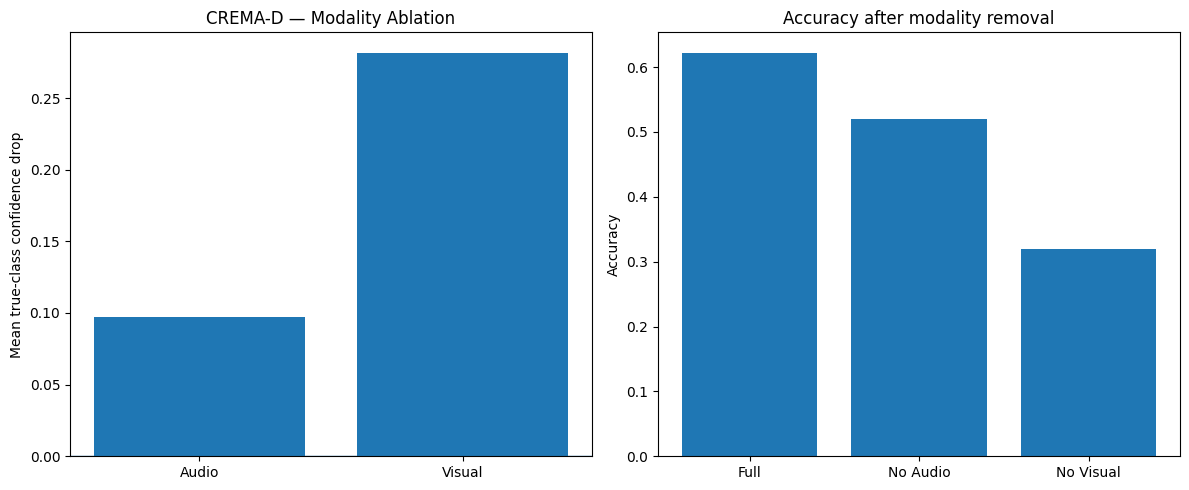

Saved: /content/DL_project/modality_bias/results/crema_d_modality_ablation.png


In [ ]:
# ============================================================
# CREMA-D — MODALITY ABLATION VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Confidence drop
axes[0].bar(
    ["Audio", "Visual"],
    [
        ablation_summary.loc[
            0,
            "Mean_audio_confidence_drop"
        ],
        ablation_summary.loc[
            0,
            "Mean_visual_confidence_drop"
        ]
    ]
)

axes[0].axhline(
    0,
    linewidth=1
)

axes[0].set_ylabel(
    "Mean true-class confidence drop"
)

axes[0].set_title(
    "CREMA-D — Modality Ablation"
)

# Accuracy
axes[1].bar(
    [
        "Full",
        "No Audio",
        "No Visual"
    ],
    [
        ablation_summary.loc[
            0,
            "Accuracy_full"
        ],
        ablation_summary.loc[
            0,
            "Accuracy_no_audio"
        ],
        ablation_summary.loc[
            0,
            "Accuracy_no_visual"
        ]
    ]
)

axes[1].set_ylabel(
    "Accuracy"
)

axes[1].set_title(
    "Accuracy after modality removal"
)

plt.tight_layout()

ABLATION_PLOT = (
    RESULTS_DIR /
    "crema_d_modality_ablation.png"
)

plt.savefig(
    ABLATION_PLOT,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ABLATION_PLOT)


## Part B — CREMA-D Layer-wise Representation Bias

This is **not layer-wise Integrated Gradients**.

We measure the average absolute activation magnitude at relative depths of the two encoders and convert the two values into a representation-energy share:

\[
S_a^{(l)}
=
rac{E_a^{(l)}}{E_a^{(l)} + E_v^{(l)} + \epsilon}
\]

\[
B^{(l)} = |S_a^{(l)} - 0.5|
\]

where \(B^{(l)}=0\) indicates equal representation-energy share and larger values indicate stronger representation imbalance.

Because the audio and visual encoders do not have identical numbers of internal blocks, stages are compared by **relative encoder depth**, not by claiming that `layer2` of one network is semantically identical to `layer2` of the other.


In [ ]:
# ============================================================
# CREMA-D — LAYER-WISE REPRESENTATION BIAS
# ============================================================

# Four comparable relative-depth points:
#   25%  -> early
#   50%  -> middle
#   75%  -> late
#   100% -> final learned embedding
#
# Audio:
#   conv1 -> conv2 -> conv3 -> embedding
#
# Visual:
#   layer1 -> layer2 -> layer3 -> embedding
#
# We intentionally do NOT claim architectural equivalence between
# the individual blocks. They are matched by relative depth.

AUDIO_STAGE_MODULES = {
    "25%_early": "0",
    "50%_middle": "4",
    "75%_late": "8"
}

VISUAL_STAGE_MODULES = {
    "25%_early": "4",   # ResNet layer1
    "50%_middle": "5",  # ResNet layer2
    "75%_late": "6"     # ResNet layer3
}


def collect_layerwise_energy(
    model,
    loader
):

    audio_energy = {
        key: []
        for key in AUDIO_STAGE_MODULES
    }

    visual_energy = {
        key: []
        for key in VISUAL_STAGE_MODULES
    }

    audio_embedding_energy = []
    visual_embedding_energy = []

    model.eval()

    with torch.no_grad():

        for batch_idx, batch in enumerate(
            loader
        ):

            audio = batch["audio"].to(
                DEVICE,
                non_blocking=True
            )

            visual = batch["visual"].to(
                DEVICE,
                non_blocking=True
            )

            # ------------------------------------------------
            # Hooks
            # ------------------------------------------------
            audio_outputs = {}
            visual_outputs = {}

            audio_hooks = []
            visual_hooks = []

            for name, module_idx in (
                AUDIO_STAGE_MODULES.items()
            ):

                module = (
                    model.audio_encoder
                    .net
                    ._modules[module_idx]
                )

                audio_hooks.append(
                    module.register_forward_hook(
                        lambda m, inp, out,
                        name=name:
                        audio_outputs.__setitem__(
                            name,
                            out.detach()
                        )
                    )
                )

            for name, module_idx in (
                VISUAL_STAGE_MODULES.items()
            ):

                module = (
                    model.visual_encoder
                    .features
                    ._modules[module_idx]
                )

                visual_hooks.append(
                    module.register_forward_hook(
                        lambda m, inp, out,
                        name=name:
                        visual_outputs.__setitem__(
                            name,
                            out.detach()
                        )
                    )
                )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------
            audio_embedding = (
                model.audio_encoder(audio)
            )

            visual_embedding = (
                model.visual_encoder(visual)
            )

            # ------------------------------------------------
            # Remove hooks
            # ------------------------------------------------
            for hook in audio_hooks:
                hook.remove()

            for hook in visual_hooks:
                hook.remove()

            # ------------------------------------------------
            # Mean absolute activation energy
            # ------------------------------------------------
            for name in audio_stage_outputs_order(
                audio_outputs
            ):
                audio_energy[name].extend(
                    audio_outputs[name]
                    .abs()
                    .mean(
                        dim=tuple(
                            range(
                                1,
                                audio_outputs[name].dim()
                            )
                        )
                    )
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

            for name in visual_stage_outputs_order(
                visual_outputs
            ):
                out = visual_outputs[name]

                # Visual hooks operate on B*T frames.
                # Convert back to [B,T] energy and average
                # over the sampled frames so each clip contributes
                # exactly one value.
                frame_energy = out.abs().mean(
                    dim=tuple(range(1, out.dim()))
                )

                clip_energy = frame_energy.reshape(
                    audio.shape[0],
                    visual.shape[1]
                ).mean(dim=1)

                visual_energy[name].extend(
                    clip_energy
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

            audio_embedding_energy.extend(
                audio_embedding.abs()
                .mean(dim=1)
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            visual_embedding_energy.extend(
                visual_embedding.abs()
                .mean(dim=1)
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            if (
                (batch_idx + 1) % 20 == 0
                or (batch_idx + 1) == len(loader)
            ):
                print(
                    f"Layer-wise progress: "
                    f"{batch_idx + 1}/{len(loader)} batches"
                )

    return (
        audio_energy,
        visual_energy,
        audio_embedding_energy,
        visual_embedding_energy
    )


def audio_stage_outputs_order(outputs):
    return [
        name
        for name in [
            "25%_early",
            "50%_middle",
            "75%_late"
        ]
        if name in outputs
    ]


def visual_stage_outputs_order(outputs):
    return [
        name
        for name in [
            "25%_early",
            "50%_middle",
            "75%_late"
        ]
        if name in outputs
    ]


(
    audio_energy,
    visual_energy,
    audio_emb_energy,
    visual_emb_energy
) = collect_layerwise_energy(
    model,
    crema_test_loader
)

layer_rows = []

for depth in [
    "25%_early",
    "50%_middle",
    "75%_late"
]:

    a = np.asarray(
        audio_energy[depth],
        dtype=np.float64
    )

    v = np.asarray(
        visual_energy[depth],
        dtype=np.float64
    )

    if len(a) != len(v):
        raise RuntimeError(
            f"Layer alignment mismatch at {depth}: "
            f"audio={len(a)}, visual={len(v)}"
        )

    audio_share = (
        a / (a + v + 1e-12)
    )

    visual_share = (
        1.0 - audio_share
    )

    layer_rows.append(
        {
            "Depth": depth,
            "Audio_energy_mean": float(
                a.mean()
            ),
            "Visual_energy_mean": float(
                v.mean()
            ),
            "Audio_share_mean": float(
                audio_share.mean()
            ),
            "Visual_share_mean": float(
                visual_share.mean()
            ),
            "Bias_magnitude": float(
                np.mean(
                    np.abs(
                        audio_share - 0.5
                    )
                )
            )
        }
    )

# Final embedding is a clean 256-D vs 256-D comparison.
a = np.asarray(
    audio_emb_energy,
    dtype=np.float64
)

v = np.asarray(
    visual_emb_energy,
    dtype=np.float64
)

embedding_audio_share = (
    a / (a + v + 1e-12)
)

layer_rows.append(
    {
        "Depth": "100%_embedding",
        "Audio_energy_mean": float(
            a.mean()
        ),
        "Visual_energy_mean": float(
            v.mean()
        ),
        "Audio_share_mean": float(
            embedding_audio_share.mean()
        ),
        "Visual_share_mean": float(
            (1.0 - embedding_audio_share).mean()
        ),
        "Bias_magnitude": float(
            np.mean(
                np.abs(
                    embedding_audio_share - 0.5
                )
            )
        )
    }
)

layerwise_df = pd.DataFrame(
    layer_rows
)

display(
    layerwise_df.round(4)
)

LAYERWISE_CSV = (
    RESULTS_DIR /
    "crema_d_layerwise_representation_bias.csv"
)

layerwise_df.to_csv(
    LAYERWISE_CSV,
    index=False
)

print("Saved:", LAYERWISE_CSV)


Layer-wise progress: 20/134 batches
Layer-wise progress: 40/134 batches
Layer-wise progress: 60/134 batches
Layer-wise progress: 80/134 batches
Layer-wise progress: 100/134 batches
Layer-wise progress: 120/134 batches
Layer-wise progress: 134/134 batches


,Depth,Audio_energy_mean,Visual_energy_mean,Audio_share_mean,Visual_share_mean,Bias_magnitude
0,25%_early,0.4012,0.4688,0.4611,0.5389,0.0389
1,50%_middle,0.5774,0.1589,0.7836,0.2164,0.2836
2,75%_late,0.6389,0.1072,0.8537,0.1463,0.3537
3,100%_embedding,0.3475,1.2042,0.2313,0.7687,0.2689


Saved: /content/DL_project/modality_bias/results/crema_d_layerwise_representation_bias.csv


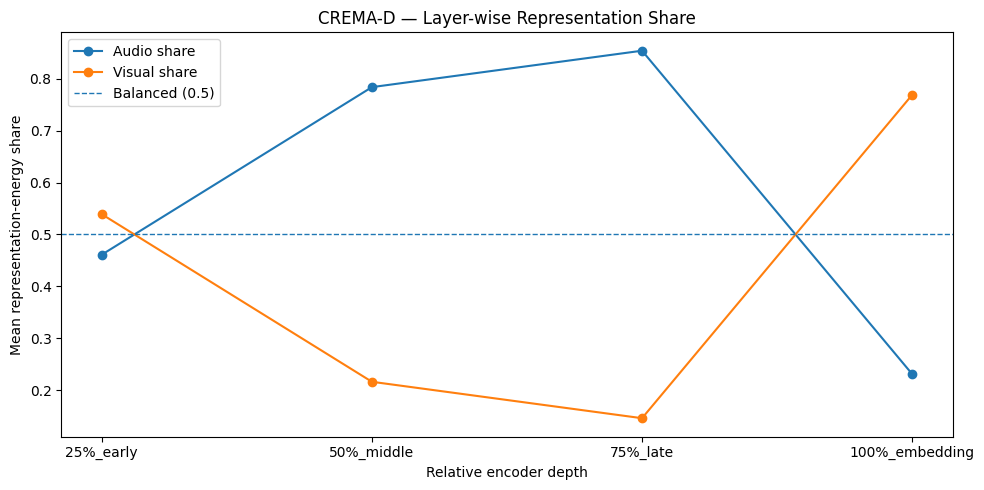

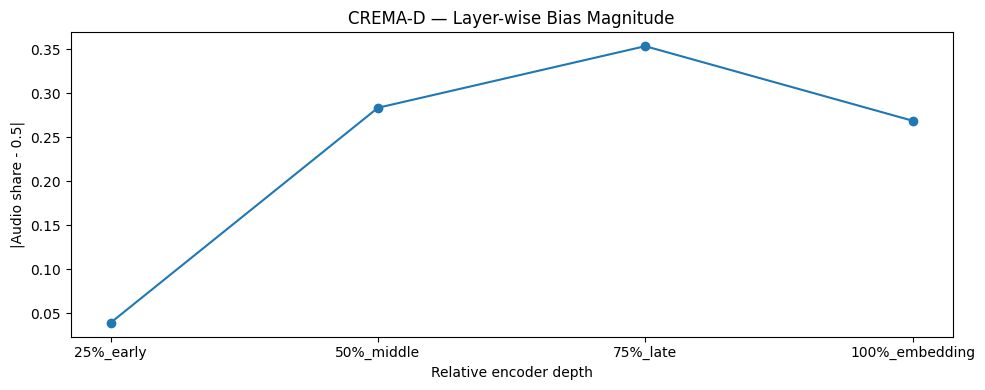

Saved: /content/DL_project/modality_bias/results/crema_d_layerwise_representation_share.png
Saved: /content/DL_project/modality_bias/results/crema_d_layerwise_bias_magnitude.png


In [ ]:
# ============================================================
# CELL 7 — LAYER-WISE BIAS VISUALIZATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

x = np.arange(
    len(layerwise_df)
)

ax.plot(
    x,
    layerwise_df[
        "Audio_share_mean"
    ],
    marker="o",
    label="Audio share"
)

ax.plot(
    x,
    layerwise_df[
        "Visual_share_mean"
    ],
    marker="o",
    label="Visual share"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Balanced (0.5)"
)

ax.set_xticks(x)
ax.set_xticklabels(
    layerwise_df["Depth"]
)

ax.set_ylabel(
    "Mean representation-energy share"
)

ax.set_xlabel(
    "Relative encoder depth"
)

ax.set_title(
    "CREMA-D — Layer-wise Representation Share"
)

ax.legend()
plt.tight_layout()

LAYER_SHARE_PLOT = (
    RESULTS_DIR /
    "crema_d_layerwise_representation_share.png"
)

plt.savefig(
    LAYER_SHARE_PLOT,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# Separate bias-magnitude plot
plt.figure(
    figsize=(10, 4)
)

plt.plot(
    x,
    layerwise_df[
        "Bias_magnitude"
    ],
    marker="o"
)

plt.xticks(
    x,
    layerwise_df["Depth"]
)

plt.ylabel(
    "|Audio share - 0.5|"
)

plt.xlabel(
    "Relative encoder depth"
)

plt.title(
    "CREMA-D — Layer-wise Bias Magnitude"
)

plt.tight_layout()

LAYER_BIAS_PLOT = (
    RESULTS_DIR /
    "crema_d_layerwise_bias_magnitude.png"
)

plt.savefig(
    LAYER_BIAS_PLOT,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LAYER_SHARE_PLOT)
print("Saved:", LAYER_BIAS_PLOT)


In [ ]:
# ============================================================
# CELL 8 — OPTIONAL LINK TO NOTEBOOK 3 XAI/MBS RESULTS
# ============================================================
# This cell does NOT recompute MBS or XAI.
# It only checks whether Notebook 3's per-sample XAI/MBS file
# exists and, if available, merges it with ablation results.

XAI_PATH = (
    RESULTS_DIR /
    "crema_d_xai_mbs_per_sample.csv"
)

if XAI_PATH.exists():

    xai_df = pd.read_csv(
        XAI_PATH
    )

    if "id" not in xai_df.columns:
        print(
            "XAI file exists but has no 'id' column; "
            "skipping merge."
        )

    else:

        xai_df["id"] = (
            xai_df["id"].astype(str)
        )

        merged = ablation_df.merge(
            xai_df,
            on="id",
            how="inner",
            validate="one_to_one"
        )

        print(
            "✓ XAI + ablation aligned samples:",
            len(merged)
        )

        if len(merged) == len(ablation_df):

            print(
                "✓ All 1065 ablation samples matched "
                "to Notebook 3 XAI results."
            )

            merged.to_csv(
                RESULTS_DIR /
                "crema_d_xai_mbs_ablation_merged.csv",
                index=False
            )

            display(
                merged[
                    [
                        "id",
                        "mbs_audio",
                        "mbs_visual",
                        "xai_audio",
                        "xai_visual",
                        "audio_confidence_drop",
                        "visual_confidence_drop"
                    ]
                ].head()
            )

        else:

            print(
                "WARNING: not all samples matched. "
                "No correlation is computed here."
            )

else:

    print(
        "Notebook 3 XAI file not found yet:"
    )

    print(XAI_PATH)

    print(
        "Run Notebook 3 first if you want the optional "
        "XAI ↔ ablation merged analysis."
    )


Notebook 3 XAI file not found yet:
/content/DL_project/modality_bias/results/crema_d_xai_mbs_per_sample.csv
Run Notebook 3 first if you want the optional XAI ↔ ablation merged analysis.


## Part C — CREMA-D Interpretation / Hand-off

This notebook establishes two diagnostic views of the **baseline**:

### 1. Modality ablation
- Larger **audio confidence drop** → the baseline relies more on audio for true-class confidence.
- Larger **visual confidence drop** → stronger visual reliance.
- Compare both confidence drop and accuracy drop; do not rely on only one metric.

### 2. Layer-wise representation bias
- `Audio_share_mean ≈ 0.5` → balanced representation energy at that relative depth.
- A larger `|Audio_share - 0.5|` → stronger representation imbalance.
- The **trend across depth** is more informative than a single layer.

### Connection to the overall research pipeline

**Baseline → MBS + ρ → XAI → XAI↔MBS → Modality Ablation → Layer-wise Bias → OPM/OGM/AGM/PMR/UDI mitigation → Proposed XAI-guided method**

Do not claim that a mitigation method is successful from ablation or layer-wise bias alone. These diagnostics should be interpreted together with test performance, MBS, ρ, XAI attribution, and later mitigation experiments.

### Output files

- `crema_d_modality_ablation_per_sample.csv`
- `crema_d_modality_ablation_summary.csv`
- `crema_d_modality_ablation.png`
- `crema_d_layerwise_representation_bias.csv`
- `crema_d_layerwise_representation_share.png`
- `crema_d_layerwise_bias_magnitude.png`
- optionally `crema_d_xai_mbs_ablation_merged.csv`


# Part D — CMU-MOSI Bias Analysis

The CMU-MOSI analysis mirrors the CREMA-D methodology, but uses its native three modalities: **text, audio, vision**.

Ablation is performed at the learned 128-D modality representation, by replacing one modality embedding with zeros while keeping the other modality embeddings unchanged. Layer-wise analysis uses the comparable hidden representation stages of the repository encoder (`Linear → ReLU → Dropout`).

In [ ]:
# ============================================================
# CMU-MOSI — DOWNLOAD DATA + EXACT MODEL + TEST REPRESENTATIONS
# ============================================================

if not CMU_PKL.exists():
    print("Downloading CMU-MOSI aligned_50.pkl...")
    downloaded = hf_hub_download(
        repo_id=CMU_REPO_ID,
        repo_type="dataset",
        filename=CMU_REMOTE_FILE,
        local_dir=str(CMU_WORK)
    )
    downloaded = Path(downloaded)
    CMU_PKL.parent.mkdir(parents=True, exist_ok=True)
    if downloaded.resolve() != CMU_PKL.resolve():
        shutil.copy2(downloaded, CMU_PKL)

print("CMU-MOSI data:", CMU_PKL)

with open(CMU_PKL, "rb") as f:
    cmu_raw = pickle.load(f)

CMU_MODALITIES = ["text", "audio", "vision"]
CMU_SPLITS = ["train", "valid", "test"]

cmu_X = {m: {} for m in CMU_MODALITIES}
cmu_y = {}
cmu_ids = {}
cmu_scalers = {}

from sklearn.preprocessing import StandardScaler

for split in CMU_SPLITS:
    part = cmu_raw[split]
    cmu_y[split] = np.asarray(part["classification_labels"]).reshape(-1).astype(np.int64)
    cmu_ids[split] = np.asarray(part["id"]).reshape(-1).astype(str)

    for m in CMU_MODALITIES:
        arr = np.asarray(part[m], dtype=np.float32)
        if arr.ndim != 3:
            raise ValueError(f"{split}/{m} expected [N,T,D], got {arr.shape}")
        cmu_X[m][split] = arr.mean(axis=1)

for m in CMU_MODALITIES:
    scaler = StandardScaler()
    scaler.fit(cmu_X[m]["train"])
    cmu_scalers[m] = scaler
    for split in CMU_SPLITS:
        cmu_X[m][split] = scaler.transform(cmu_X[m][split]).astype(np.float32)

CMU_INPUT_DIMS = {m: cmu_X[m]["train"].shape[1] for m in CMU_MODALITIES}
print("CMU-MOSI input dimensions:", CMU_INPUT_DIMS)
print("CMU-MOSI test samples:", len(cmu_y["test"]))

class CMUMOSIBaselineBias(nn.Module):
    def __init__(self, input_dims, hidden_dim=128, num_classes=3, dropout=0.2):
        super().__init__()
        self.encoders = nn.ModuleDict({
            m: nn.Sequential(
                nn.Linear(input_dims[m], hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for m in CMU_MODALITIES
        })
        self.modality_heads = nn.ModuleDict({
            m: nn.Linear(hidden_dim, num_classes)
            for m in CMU_MODALITIES
        })
        self.fusion_head = nn.Sequential(
            nn.Linear(hidden_dim * len(CMU_MODALITIES), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def encode(self, inputs):
        return {m: self.encoders[m](inputs[m]) for m in CMU_MODALITIES}

    def forward(self, inputs):
        emb = self.encode(inputs)
        modality_logits = {m: self.modality_heads[m](emb[m]) for m in CMU_MODALITIES}
        fused_logits = self.fusion_head(torch.cat([emb[m] for m in CMU_MODALITIES], dim=1))
        return fused_logits, modality_logits

cmu_ckpt = torch.load(CMU_CKPT, map_location="cpu", weights_only=False)
cmu_model = CMUMOSIBaselineBias(CMU_INPUT_DIMS, hidden_dim=128, num_classes=3, dropout=0.2).to(DEVICE)
cmu_model.load_state_dict(cmu_ckpt, strict=True)
cmu_model.eval()
print("✓ CMU-MOSI checkpoint loaded")

class CMUTestDataset(Dataset):
    def __init__(self, X_dict, labels, ids):
        self.X = X_dict
        self.labels = labels
        self.ids = ids
        self.n = len(labels)
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        return {
            "text": torch.from_numpy(self.X["text"][idx]).float(),
            "audio": torch.from_numpy(self.X["audio"][idx]).float(),
            "vision": torch.from_numpy(self.X["vision"][idx]).float(),
            "label": int(self.labels[idx]),
            "id": self.ids[idx]
        }

CMU_BIAS_BATCH_SIZE = 64
cmu_test_ds = CMUTestDataset(
    {m: cmu_X[m]["test"] for m in CMU_MODALITIES},
    cmu_y["test"],
    cmu_ids["test"]
)
cmu_loader = DataLoader(cmu_test_ds, batch_size=CMU_BIAS_BATCH_SIZE, shuffle=False)

# Align existing MBS by sample ID; never silently truncate.
cmu_mbs = pd.read_csv(CMU_MBS)
required_cmu_mbs = {"sample_id", "text_MBS", "audio_MBS", "vision_MBS"}
if not required_cmu_mbs.issubset(cmu_mbs.columns):
    raise ValueError(f"CMU MBS missing columns: {required_cmu_mbs - set(cmu_mbs.columns)}")

cmu_mbs["sample_id"] = cmu_mbs["sample_id"].astype(str)
cmu_test_order = pd.DataFrame({"sample_id": cmu_ids["test"], "true_label": cmu_y["test"]})
cmu_test_order["sample_id"] = cmu_test_order["sample_id"].astype(str)
if set(cmu_test_order["sample_id"]) != set(cmu_mbs["sample_id"]):
    raise ValueError("CMU-MOSI test IDs and MBS IDs do not match exactly.")
cmu_mbs_ordered = cmu_test_order.merge(cmu_mbs[["sample_id","text_MBS","audio_MBS","vision_MBS"]], on="sample_id", how="left", validate="one_to_one")
print("✓ CMU-MOSI MBS aligned by sample ID")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Processed/aligned_50.pkl: reconstructing file:   0%|          |  0.00B /  367MB            

Processed/aligned_50.pkl: downloading bytes:           |  0.00B            

CMU-MOSI data: /content/cmu_mosi_bias_data/Processed/aligned_50.pkl
CMU-MOSI input dimensions: {'text': 768, 'audio': 5, 'vision': 20}
CMU-MOSI test samples: 686
✓ CMU-MOSI checkpoint loaded
✓ CMU-MOSI MBS aligned by sample ID


In [ ]:
# ============================================================
# CMU-MOSI — MODALITY ABLATION
# ============================================================

def run_cmu_modality_ablation(model, loader):
    model.eval()
    rows = []
    with torch.no_grad():
        for batch in loader:
            inputs = {m: batch[m].to(DEVICE, non_blocking=True) for m in CMU_MODALITIES}
            y = batch["label"].to(DEVICE)
            emb = model.encode(inputs)

            full_logits = model.fusion_head(torch.cat([emb[m] for m in CMU_MODALITIES], dim=1))
            full_prob = torch.softmax(full_logits, dim=1)
            idx = torch.arange(len(y), device=DEVICE)
            full_conf = full_prob[idx, y]
            full_pred = full_logits.argmax(1)

            sample_rows = {
                "sample_id": list(batch["id"]),
                "true_label": y.cpu().numpy().astype(int),
                "full_confidence": full_conf.cpu().numpy(),
                "full_prediction": full_pred.cpu().numpy().astype(int),
                "full_correct": (full_pred == y).cpu().numpy().astype(int)
            }

            for removed in CMU_MODALITIES:
                ablated = {m: (torch.zeros_like(emb[m]) if m == removed else emb[m]) for m in CMU_MODALITIES}
                logits = model.fusion_head(torch.cat([ablated[m] for m in CMU_MODALITIES], dim=1))
                prob = torch.softmax(logits, dim=1)
                conf = prob[idx, y]
                pred = logits.argmax(1)
                drop = full_conf - conf
                key = removed
                sample_rows[f"{key}_confidence_no_modality"] = conf.cpu().numpy()
                sample_rows[f"{key}_confidence_drop"] = drop.cpu().numpy()
                sample_rows[f"{key}_prediction_no_modality"] = pred.cpu().numpy().astype(int)
                sample_rows[f"{key}_prediction_flip"] = (pred != full_pred).cpu().numpy().astype(int)
                sample_rows[f"{key}_correct_no_modality"] = (pred == y).cpu().numpy().astype(int)

            n = len(y)
            for j in range(n):
                row = {k: sample_rows[k][j] for k in sample_rows}
                rows.append(row)

    return pd.DataFrame(rows)

cmu_ablation_df = run_cmu_modality_ablation(cmu_model, cmu_loader)

summary_rows = []
for m in CMU_MODALITIES:
    summary_rows.append({
        "dataset": "CMU-MOSI",
        "modality_removed": m,
        "n": len(cmu_ablation_df),
        "Accuracy_full": cmu_ablation_df["full_correct"].mean(),
        "Accuracy_without_modality": cmu_ablation_df[f"{m}_correct_no_modality"].mean(),
        "Accuracy_drop": cmu_ablation_df["full_correct"].mean() - cmu_ablation_df[f"{m}_correct_no_modality"].mean(),
        "Mean_confidence_drop": cmu_ablation_df[f"{m}_confidence_drop"].mean(),
        "Prediction_flip_rate": cmu_ablation_df[f"{m}_prediction_flip"].mean()
    })
cmu_ablation_summary = pd.DataFrame(summary_rows)

CMU_ABLATION_CSV = RESULTS_DIR / "cmu_mosi_modality_ablation_per_sample.csv"
CMU_ABLATION_SUMMARY_CSV = RESULTS_DIR / "cmu_mosi_modality_ablation_summary.csv"
cmu_ablation_df.to_csv(CMU_ABLATION_CSV, index=False)
cmu_ablation_summary.to_csv(CMU_ABLATION_SUMMARY_CSV, index=False)

print("✓ CMU-MOSI ablation completed:", len(cmu_ablation_df))
display(cmu_ablation_summary)
print("Saved:", CMU_ABLATION_CSV)
print("Saved:", CMU_ABLATION_SUMMARY_CSV)


✓ CMU-MOSI ablation completed: 686


,dataset,modality_removed,n,Accuracy_full,Accuracy_without_modality,Accuracy_drop,Mean_confidence_drop,Prediction_flip_rate
0,CMU-MOSI,text,686,0.755102,0.444606,0.310496,0.279698,0.485423
1,CMU-MOSI,audio,686,0.755102,0.755102,0.000000,0.014618,0.034985
2,CMU-MOSI,vision,686,0.755102,0.759475,-0.004373,0.010464,0.040816


Saved: /content/DL_project/modality_bias/results/cmu_mosi_modality_ablation_per_sample.csv
Saved: /content/DL_project/modality_bias/results/cmu_mosi_modality_ablation_summary.csv


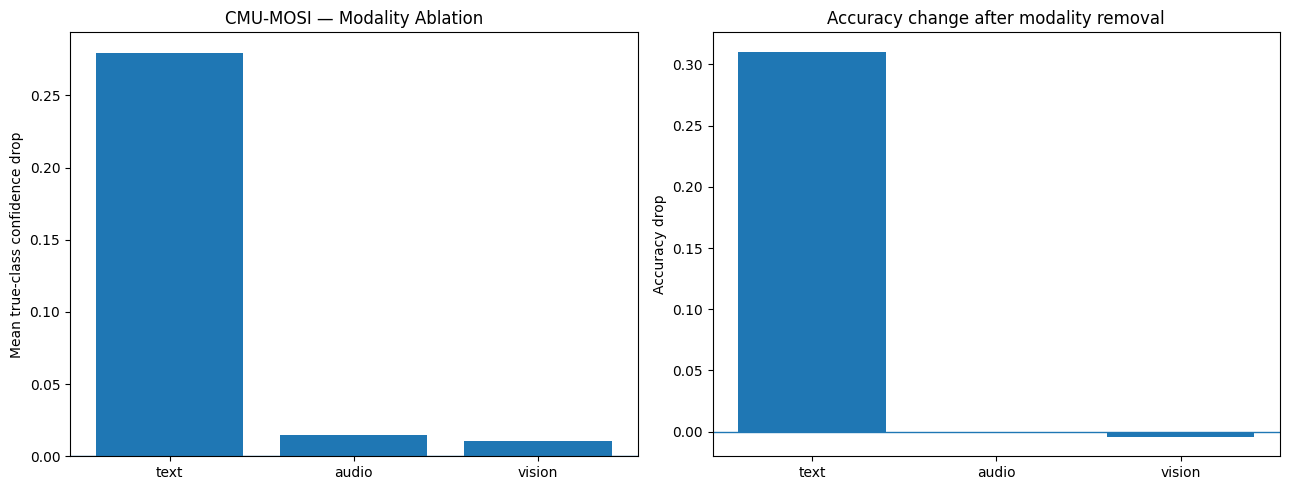

Saved: /content/DL_project/modality_bias/results/cmu_mosi_modality_ablation.png


In [ ]:
# ============================================================
# CMU-MOSI — MODALITY ABLATION VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    cmu_ablation_summary["modality_removed"],
    cmu_ablation_summary["Mean_confidence_drop"]
)
axes[0].axhline(0, linewidth=1)
axes[0].set_ylabel("Mean true-class confidence drop")
axes[0].set_title("CMU-MOSI — Modality Ablation")

axes[1].bar(
    cmu_ablation_summary["modality_removed"],
    cmu_ablation_summary["Accuracy_drop"]
)
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Accuracy drop")
axes[1].set_title("Accuracy change after modality removal")

plt.tight_layout()
CMU_ABLATION_PLOT = RESULTS_DIR / "cmu_mosi_modality_ablation.png"
plt.savefig(CMU_ABLATION_PLOT, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", CMU_ABLATION_PLOT)


In [ ]:
# ============================================================
# CMU-MOSI — LAYER-WISE REPRESENTATION BIAS
# ============================================================

# The CMU encoder is Linear -> ReLU -> Dropout. We compare two
# representation stages with equal 128-D dimensionality:
#   50%: Linear pre-activation
#   100%: Encoder output after ReLU/Dropout (Dropout is inactive in eval mode)
# We do NOT compare raw input energy because input dimensions differ
# (text=768, audio=5, vision=20), which would make raw norms misleading.

def collect_cmu_layerwise_bias(model, loader):
    model.eval()
    stage_values = {
        "50%_linear_pre_activation": {m: [] for m in CMU_MODALITIES},
        "100%_encoder_output": {m: [] for m in CMU_MODALITIES}
    }

    for batch in loader:
        inputs = {m: batch[m].to(DEVICE, non_blocking=True) for m in CMU_MODALITIES}
        with torch.no_grad():
            for m in CMU_MODALITIES:
                linear_out = model.encoders[m][0](inputs[m])
                encoder_out = model.encoders[m](inputs[m])
                stage_values["50%_linear_pre_activation"][m].append(linear_out.cpu().numpy())
                stage_values["100%_encoder_output"][m].append(encoder_out.cpu().numpy())

    rows = []
    for stage in stage_values:
        arrays = {m: np.concatenate(stage_values[stage][m], axis=0) for m in CMU_MODALITIES}
        energies = {m: np.sum(arrays[m] ** 2, axis=1) for m in CMU_MODALITIES}
        denom = np.sum(np.stack([energies[m] for m in CMU_MODALITIES], axis=1), axis=1) + 1e-12
        shares = {m: energies[m] / denom for m in CMU_MODALITIES}
        for i in range(len(cmu_ids["test"])):
            row = {"sample_id": cmu_ids["test"][i], "stage": stage}
            for m in CMU_MODALITIES:
                row[f"{m}_energy"] = float(energies[m][i])
                row[f"{m}_share"] = float(shares[m][i])
                row[f"{m}_bias_magnitude"] = float(abs(shares[m][i] - 1.0/3.0))
            rows.append(row)
    return pd.DataFrame(rows)

cmu_layerwise_df = collect_cmu_layerwise_bias(cmu_model, cmu_loader)
CMU_LAYERWISE_CSV = RESULTS_DIR / "cmu_mosi_layerwise_representation_bias.csv"
cmu_layerwise_df.to_csv(CMU_LAYERWISE_CSV, index=False)

cmu_layer_summary = (
    cmu_layerwise_df
    .groupby("stage")
    .agg({**{f"{m}_share":"mean" for m in CMU_MODALITIES},
          **{f"{m}_bias_magnitude":"mean" for m in CMU_MODALITIES}})
    .reset_index()
)
CMU_LAYERWISE_SUMMARY_CSV = RESULTS_DIR / "cmu_mosi_layerwise_representation_bias_summary.csv"
cmu_layer_summary.to_csv(CMU_LAYERWISE_SUMMARY_CSV, index=False)

print("✓ CMU-MOSI layer-wise analysis completed")
display(cmu_layer_summary)
print("Saved:", CMU_LAYERWISE_CSV)
print("Saved:", CMU_LAYERWISE_SUMMARY_CSV)


✓ CMU-MOSI layer-wise analysis completed


,stage,text_share,audio_share,vision_share,text_bias_magnitude,audio_bias_magnitude,vision_bias_magnitude
0,100%_encoder_output,0.671612,0.189210,0.139178,0.345633,0.165745,0.202937
1,50%_linear_pre_activation,0.684038,0.176345,0.139616,0.356266,0.175663,0.200621


Saved: /content/DL_project/modality_bias/results/cmu_mosi_layerwise_representation_bias.csv
Saved: /content/DL_project/modality_bias/results/cmu_mosi_layerwise_representation_bias_summary.csv


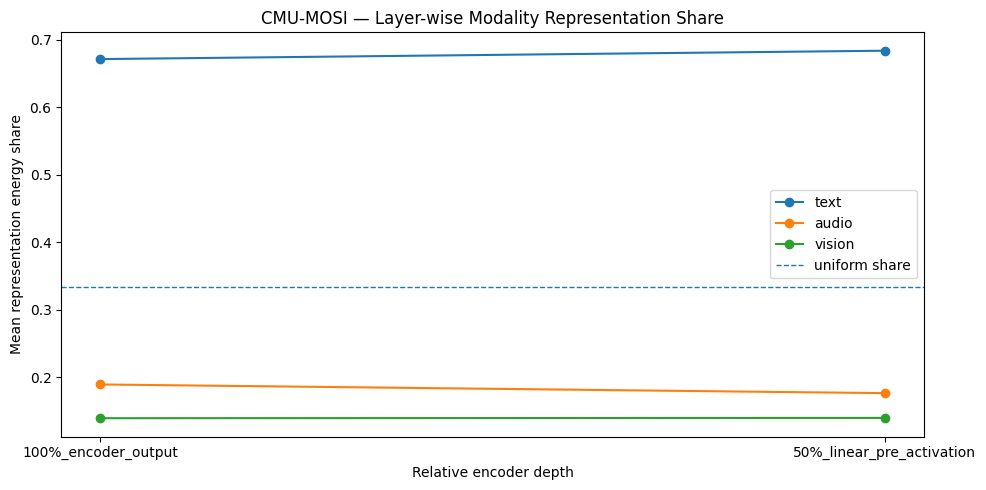

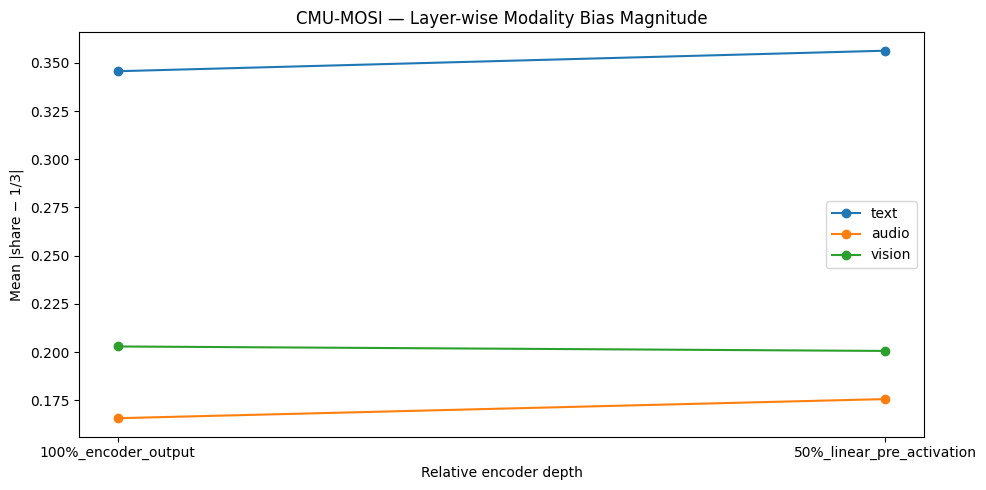

Saved: /content/DL_project/modality_bias/results/cmu_mosi_layerwise_representation_share.png
Saved: /content/DL_project/modality_bias/results/cmu_mosi_layerwise_bias_magnitude.png


In [ ]:
# ============================================================
# CMU-MOSI — LAYER-WISE VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
for m in CMU_MODALITIES:
    ax.plot(cmu_layer_summary["stage"], cmu_layer_summary[f"{m}_share"], marker="o", label=m)
ax.axhline(1.0/3.0, linewidth=1, linestyle="--", label="uniform share")
ax.set_ylabel("Mean representation energy share")
ax.set_xlabel("Relative encoder depth")
ax.set_title("CMU-MOSI — Layer-wise Modality Representation Share")
ax.legend()
plt.tight_layout()
CMU_LAYER_SHARE_PLOT = RESULTS_DIR / "cmu_mosi_layerwise_representation_share.png"
plt.savefig(CMU_LAYER_SHARE_PLOT, dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for m in CMU_MODALITIES:
    ax.plot(cmu_layer_summary["stage"], cmu_layer_summary[f"{m}_bias_magnitude"], marker="o", label=m)
ax.set_ylabel("Mean |share − 1/3|")
ax.set_xlabel("Relative encoder depth")
ax.set_title("CMU-MOSI — Layer-wise Modality Bias Magnitude")
ax.legend()
plt.tight_layout()
CMU_LAYER_BIAS_PLOT = RESULTS_DIR / "cmu_mosi_layerwise_bias_magnitude.png"
plt.savefig(CMU_LAYER_BIAS_PLOT, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", CMU_LAYER_SHARE_PLOT)
print("Saved:", CMU_LAYER_BIAS_PLOT)


In [ ]:
# ============================================================
# FINAL — CROSS-DATASET BIAS ANALYSIS SUMMARY
# ============================================================

# CREMA summary already exists as `ablation_summary`.
crema_summary_for_compare = pd.DataFrame({
    "dataset": ["CREMA-D"] * 2,
    "modality_removed": ["audio", "visual"],
    "Accuracy_full": [ablation_summary.loc[0, "Accuracy_full"]] * 2,
    "Accuracy_without_modality": [
        ablation_summary.loc[0, "Accuracy_no_audio"],
        ablation_summary.loc[0, "Accuracy_no_visual"]
    ],
    "Accuracy_drop": [
        ablation_summary.loc[0, "Accuracy_full"] - ablation_summary.loc[0, "Accuracy_no_audio"],
        ablation_summary.loc[0, "Accuracy_full"] - ablation_summary.loc[0, "Accuracy_no_visual"]
    ],
    "Mean_confidence_drop": [
        ablation_summary.loc[0, "Mean_audio_confidence_drop"],
        ablation_summary.loc[0, "Mean_visual_confidence_drop"]
    ],
    "Prediction_flip_rate": [
        ablation_summary.loc[0, "Audio_prediction_flip_rate"],
        ablation_summary.loc[0, "Visual_prediction_flip_rate"]
    ]
})

comparison = pd.concat([crema_summary_for_compare, cmu_ablation_summary], ignore_index=True)
COMPARISON_CSV = RESULTS_DIR / "bias_analysis_ablation_comparison_crema_d_cmu.csv"
comparison.to_csv(COMPARISON_CSV, index=False)

print("Cross-dataset modality ablation comparison")
display(comparison)
print("Saved:", COMPARISON_CSV)

print("\nMethodological reminder:")
print("• MBS is logit-based and independent of XAI.")
print("• Ablation is representation-level, not raw-input zeroing.")
print("• Layer-wise bias is representation-energy bias, not layer-wise IG.")
print("• CREMA-D uses 2 modalities; CMU-MOSI uses 3 modalities, so the neutral share is 1/2 vs 1/3.")


Cross-dataset modality ablation comparison


,dataset,modality_removed,Accuracy_full,Accuracy_without_modality,Accuracy_drop,Mean_confidence_drop,Prediction_flip_rate,n
0,CREMA-D,audio,0.622535,0.520188,0.102347,0.096924,0.233803,NaN
1,CREMA-D,visual,0.622535,0.319249,0.303286,0.281768,0.631925,NaN
2,CMU-MOSI,text,0.755102,0.444606,0.310496,0.279698,0.485423,686.0
3,CMU-MOSI,audio,0.755102,0.755102,0.000000,0.014618,0.034985,686.0
4,CMU-MOSI,vision,0.755102,0.759475,-0.004373,0.010464,0.040816,686.0


Saved: /content/DL_project/modality_bias/results/bias_analysis_ablation_comparison_crema_d_cmu.csv

Methodological reminder:
• MBS is logit-based and independent of XAI.
• Ablation is representation-level, not raw-input zeroing.
• Layer-wise bias is representation-energy bias, not layer-wise IG.
• CREMA-D uses 2 modalities; CMU-MOSI uses 3 modalities, so the neutral share is 1/2 vs 1/3.


## How to interpret the combined results

1. **Modality ablation:** a larger confidence/accuracy drop after removing a modality indicates stronger reliance on that modality.
2. **Layer-wise representation bias:** a modality whose energy share moves farther from the neutral share (1/2 for CREMA-D, 1/3 for CMU-MOSI) is increasingly dominant in the learned representation.
3. **XAI connection:** after running Notebook 3, merge the per-sample XAI/MBS outputs with the ablation CSVs by sample ID. This lets you test whether attribution-based reliance agrees with behavioral reliance from ablation.
4. **Do not compare raw bias magnitudes between CREMA-D and CMU-MOSI without accounting for the different number of modalities.** Compare each dataset against its own neutral share.
5. The notebook is **baseline-only**. OGM-GE/AGM/PMR/UDI should be compared only after retraining them with the same exact architecture and initialization.